# Importing the packages and data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from texttable import Texttable
import latextable

In [3]:
import sys
sys.path.insert(1, '../sar_dirichlet')
import dirichlet_regression

In [4]:
from func_test import cos_similarity, rmse_aitchison

In [5]:
scipy.__version__

'1.10.1'

# Loading Dataset

In [5]:
Y_occitanie = pd.read_csv('Data Dirichlet/occitanie/Y_occitanie.csv', sep=';')

In [6]:
X_occitanie = pd.read_csv('Data Dirichlet/occitanie/X_occitanie.csv', sep=';')

In [7]:
X_occitanie_bis = pd.read_csv('Data Dirichlet/occitanie/X_occitanie_bis.csv', sep=';')

In [8]:
coordinates = pd.read_csv('Data Dirichlet/occitanie/coordinates_cendroids.csv', sep=';')
distance_matrix = scipy.spatial.distance_matrix(coordinates,coordinates)

In [8]:
X_occitanie

,dep_canton,POP,age_mineur,age_1824,age_2540,age_4055,age_5564,age_65,PIMP13,MED13,...,no_diplom,capbep,bac,diplom_sup,french,foreign,unemp_rate,employ_evol,owner_rate,income_rate
0,09_04,10686.00000,1745.432828,633.702526,1519.569182,2022.546303,1637.837488,3126.911673,1534.935651,17225.92056,...,3084.717115,2060.336850,1491.085449,1959.678274,10175.94126,510.058743,0.146153,-1.069783,0.613769,0.467825557
1,09_06,13248.00000,2609.587595,629.992708,1880.992367,2713.380702,2161.124558,3252.922069,1114.436913,16809.71966,...,3744.620133,2624.381082,1815.069962,2178.892325,12472.42430,775.575696,0.149798,-1.986204,0.700856,0.417548487
2,09_10,13304.00000,3212.791456,779.945838,2402.657503,2871.416012,1518.065046,2519.124145,1621.879453,18847.56366,...,3092.683829,2659.588509,1821.080501,2154.021975,12857.59935,446.400655,0.119585,0.215514,0.657686,0.47024629
3,11_02,15448.38045,3236.015033,1332.042735,2472.243775,3062.868917,1930.683069,3414.526923,3381.464244,17087.33333,...,3988.595203,2507.078388,2172.484668,2919.694058,14257.99939,1190.381062,0.184913,-0.684689,0.463652,0.465530812
4,11_03,20618.51872,4469.611276,1502.609556,3212.323704,4271.437340,2738.220953,4424.315890,3596.385003,18267.50694,...,4785.628253,3539.881007,2999.019653,4096.806972,19392.86290,1225.655818,0.161466,-0.649563,0.562317,0.490678223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,82_11,14631.00000,3195.583294,757.466782,2371.208971,3139.218175,2098.865160,3068.657619,606.473438,18890.51048,...,4025.455333,3042.238466,1944.329025,2108.219105,14187.17388,443.826118,0.105342,-0.239769,0.752094,0.4734375
203,82_12,13558.00000,2588.237464,577.301835,1746.944956,2768.136801,2158.324794,3719.054149,422.444210,17457.72775,...,3769.506710,2844.033122,1912.696566,2222.628774,12573.17884,984.821162,0.118216,0.014046,0.755715,0.444210526
204,82_13,18862.00000,4648.579189,977.759331,3311.970574,4315.356878,2403.994498,3204.339530,697.987952,19849.47189,...,4130.059689,3772.243391,2526.645881,3347.924377,18149.95052,712.049477,0.110703,0.979463,0.768029,0.493975904
205,82_14,13364.00000,2627.010920,834.264654,1990.070382,2757.346600,1930.498564,3224.808880,1009.300645,17756.25360,...,4304.060809,2769.575874,1609.658404,1751.410833,12536.14180,827.858196,0.141431,0.630300,0.647832,0.433548387


In [9]:
X_occitanie['age_1840'] = X_occitanie['age_1824'] + X_occitanie['age_2540']
X_occitanie['age_4064'] = X_occitanie['age_4055'] + X_occitanie['age_5564']

In [10]:
X_occitanie['<bac'] = X_occitanie['no_diplom'] + X_occitanie['capbep']

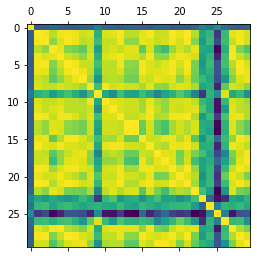

In [127]:
plt.matshow(X_occitanie.corr())

In [11]:
X_occitanie.columns

Index(['dep_canton', 'POP', 'age_mineur', 'age_1824', 'age_2540', 'age_4055',
       'age_5564', 'age_65', 'PIMP13', 'MED13', 'NBMENFISC13', 'P14_CHOM1564',
       'P14_ACT1564', 'P14_EMPLT', 'P09_EMPLT', 'P14_RP_PROP', 'P14_RP',
       'no_diplom', 'capbep', 'bac', 'diplom_sup', 'french', 'foreign',
       'unemp_rate', 'employ_evol', 'owner_rate', 'income_rate', 'age_1840',
       'age_4064', '<bac'],
      dtype='object')

In [12]:
#subset_X = X_occitanie[['POP','MED13','foreign','unemp_rate','employ_evol','owner_rate']]
#subset_X = X_occitanie[['POP','MED13','unemp_rate','employ_evol','owner_rate']]
subset_X = X_occitanie[['unemp_rate', 'employ_evol', 'owner_rate', 'foreign']]

In [13]:
subset_X.corr()

,unemp_rate,employ_evol,owner_rate,foreign
unemp_rate,1.000000,-0.191882,-0.676923,0.467411
employ_evol,-0.191882,1.000000,0.017468,0.219071
owner_rate,-0.676923,0.017468,1.000000,-0.757590
foreign,0.467411,0.219071,-0.757590,1.000000


In [14]:
def ilr_transform(data, basis):
    """
    Performs ILR transformation: y = ln(x) * V
    where basis V is a (D x D-1) matrix with orthonormal columns summing to 0.
    """
    log_data = np.log(data)
    return np.dot(log_data, basis)

In [15]:
# V_dip (2x3 in R, transposed to 3x2 for multiplication)
V_dip = np.array([
    [1/np.sqrt(6), 1/np.sqrt(6), -2/np.sqrt(6)],
    [1/np.sqrt(2), -1/np.sqrt(2), 0]
]).T

# V_employ (4x5 in R, transposed to 5x4)
V_employ = np.array([
    [-1/2/np.sqrt(5), -1/2/np.sqrt(5), -1/2/np.sqrt(5), -1/2/np.sqrt(5), 2/np.sqrt(5)],
    [-np.sqrt(3)/6, -np.sqrt(3)/6, -np.sqrt(3)/6, np.sqrt(3/4), 0],
    [-np.sqrt(2/3)/2, -np.sqrt(2/3)/2, np.sqrt(2/3), 0, 0],
    [np.sqrt(1/2), -np.sqrt(1/2), 0, 0, 0]
]).T

# Default Helmert Basis for age3 (D=3)
# In R, ilr(age3) uses: 
# Col 1: [1/sqrt(2), -1/sqrt(2), 0]
# Col 2: [1/sqrt(6), 1/sqrt(6), -2/sqrt(6)]
V_age = np.array([
    [1/np.sqrt(2), -1/np.sqrt(2), 0],
    [1/np.sqrt(6), 1/np.sqrt(6), -2/np.sqrt(6)]
]).T

In [16]:
age3_cols = ['age_1840', 'age_4064', 'age_65']
age3_data = X_occitanie[age3_cols].values

diplome3_cols = ['diplom_sup', 'bac', '<bac']
diplome3_data = X_occitanie[diplome3_cols].values

employ_cols = ['AZ', 'BE', 'FZ', 'GU', 'OQ']
employ_data = X_occitanie_bis[employ_cols].values

age3_ilr = ilr_transform(age3_data, V_age)
diplome3_ilr = ilr_transform(diplome3_data, V_dip)
employ_ilr = ilr_transform(employ_data, V_employ)

In [17]:
# We replace the NaN in the column "incomte_rate" by using a RF Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

# 1. Select the columns to use for imputation
cols_to_use = ['unemp_rate', 'employ_evol', 'owner_rate', 'income_rate']
data_subset = X_occitanie[cols_to_use]

# 2. Define the imputer (matching missForest logic)
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100), 
    random_state=0,
    max_iter=10
)

# 3. Fit and transform
imputed_data = imputer.fit_transform(data_subset)

# 4. Put the imputed column back
X_occitanie['income_rate'] = imputed_data[:, 3]

C:\Users\tnguyen001\AppData\Roaming\Python\Python38\site-packages\sklearn\impute\_iterative.py:800: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [18]:
# 5. Assemble the final x2 dataframe
x2_df = pd.DataFrame()

# Compositional coordinates
x2_df[['age3_ilr1', 'age3_ilr2']] = age3_ilr
x2_df[['diplome3_ilr1', 'diplome3_ilr2']] = diplome3_ilr
x2_df[['employ_ilr1', 'employ_ilr2', 'employ_ilr3', 'employ_ilr4']] = employ_ilr

# Other variables
x2_df['unemp_rate'] = X_occitanie['unemp_rate'].values
x2_df['employ_evol'] = X_occitanie['employ_evol'].values
x2_df['owner_rate'] = X_occitanie['owner_rate'].values
x2_df['income_rate'] = X_occitanie['income_rate'].values
x2_df['foreign'] = np.log(X_occitanie['foreign'].values)
#x2_df['voters'] = np.log(X_occitanie['NBRINS'].values)
x2_df['pop'] = np.log(X_occitanie['POP'].values)

# Reset index to match original if necessary
x2_df.index = X_occitanie.index

In [19]:
x2_df_all_but_pop = x2_df.drop(columns=['pop'])

In [19]:
x2_df_all_but_pop.to_csv('Data Dirichlet/occitanie/X_occitanie_final.csv', index=False)

In [549]:
x2_df = x2_df.drop(columns=['employ_evol'])
x2_df = x2_df.drop(columns=['unemp_rate'])
x2_df = x2_df.drop(columns=['pop'])

In [456]:
x2_df.corr()

,age3_ilr1,age3_ilr2,diplome3_ilr1,diplome3_ilr2,employ_ilr1,employ_ilr2,employ_ilr3,employ_ilr4,unemp_rate,owner_rate,income_rate,foreign,pop
age3_ilr1,1.000000,0.783245,0.694257,0.724917,0.688859,0.764471,0.648739,-0.761479,0.382589,-0.849866,0.219433,0.631397,0.529447
age3_ilr2,0.783245,1.000000,0.792391,0.802234,0.379627,0.523411,0.574401,-0.600139,0.012661,-0.470968,0.494513,0.512546,0.620353
diplome3_ilr1,0.694257,0.792391,1.000000,0.956660,0.442895,0.631667,0.648778,-0.651365,-0.059227,-0.478701,0.683641,0.461918,0.563357
diplome3_ilr2,0.724917,0.802234,0.956660,1.000000,0.469190,0.649704,0.643090,-0.700081,-0.012371,-0.521900,0.633208,0.495378,0.573526
employ_ilr1,0.688859,0.379627,0.442895,0.469190,1.000000,0.823827,0.636960,-0.609121,0.566108,-0.827891,0.011139,0.492200,0.309849
employ_ilr2,0.764471,0.523411,0.631667,0.649704,0.823827,1.000000,0.826313,-0.824978,0.564052,-0.854643,0.191525,0.680748,0.561064
employ_ilr3,0.648739,0.574401,0.648778,0.643090,0.636960,0.826313,1.000000,-0.683026,0.451645,-0.627544,0.271726,0.660744,0.656657
employ_ilr4,-0.761479,-0.600139,-0.651365,-0.700081,-0.609121,-0.824978,-0.683026,1.000000,-0.372212,0.741223,-0.288712,-0.610105,-0.547351
unemp_rate,0.382589,0.012661,-0.059227,-0.012371,0.566108,0.564052,0.451645,-0.372212,1.000000,-0.676923,-0.562482,0.645973,0.382393
owner_rate,-0.849866,-0.470968,-0.478701,-0.521900,-0.827891,-0.854643,-0.627544,0.741223,-0.676923,1.000000,0.079009,-0.690285,-0.441700


# Performing the Dirichlet regression

In [20]:
#X = np.array(x2_df)
X = np.array(x2_df_all_but_pop)
Y = np.array(Y_occitanie)

In [21]:
X.shape

(207, 13)

In [ ]:
#X = StandardScaler().fit(X).transform(X)
#X = MinMaxScaler().fit(X).transform(X)

In [22]:
#Z = np.ones((207,1))
#gamma_0 = [0.]
Z = np.copy(X)
Z = Z[:,2:4] #we select only the columns with a significant value at the Wald test (p-value > 0.05)
gamma_0 = Z.shape[1] * [0.]

In [23]:
n,K = X.shape
J = Y.shape[1]

In [24]:
K*J

39

In [25]:
K

13

## Without spatial

In [60]:
%%time
dirichRegressor = dirichlet_regression.dirichletRegressor()
dirichRegressor.fit(X, Y, parametrization='alternative', gamma_0=gamma_0, Z=Z)

Optimization terminated successfully.
Wall time: 209 ms


In [391]:
# Loglikelihood avec tout ('pop', 'employ_evol' et 'unemp_rate')
loglik_ns = dirichlet_regression.dirichlet_loglikelihood(dirichRegressor.mu,dirichRegressor.phi,Y)
print(loglik_ns)

497.6288334608972


In [579]:
# Loglikelihood sans 'pop' 
loglik_ns = dirichlet_regression.dirichlet_loglikelihood(dirichRegressor.mu,dirichRegressor.phi,Y)
print(loglik_ns)

488.9096860577178


In [62]:
print('R2:',r2_score(Y,dirichRegressor.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor.mu,dirichRegressor.phi,Y)+2*30)
print('Cos similarity:',cos_similarity(Y,dirichRegressor.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor.mu))

R2: 0.42170502140601557
RMSE: 0.08471138222097711
Cross-entropy: -1.0508958606451773
AIC: -916.627232350864
Cos similarity: 0.9721837457862622
RMSE_A: 0.40297074767394897


In [64]:
k = len(dirichRegressor.beta.flatten()) + len(dirichRegressor.gamma.flatten())
print('R2 adjusted : ', 1 - (1 - 0.42170502140601557) * (n-1)/(n-k))

R2 adjusted :  0.3269561266081311


In [519]:
1 - chi2.cdf(2*(497.6 - 488.9), 2)

0.00016658581098760727

In [468]:
# Loglikelihood sans 'employ_evol' et sans 'pop'
loglik_ns = dirichlet_regression.dirichlet_loglikelihood(dirichRegressor.mu,dirichRegressor.phi,Y)
print(loglik_ns)

487.34430482025044


In [560]:
# Loglikelihood sans 'employ_evol', sans 'pop' et sans 'unemp_rate'
loglik_ns = dirichlet_regression.dirichlet_loglikelihood(dirichRegressor.mu,dirichRegressor.phi,Y)
print(loglik_ns)

472.2846926726399


In [492]:
1 - chi2.cdf(2*(487.3 - 472.3), 2)

3.059023204743383e-07

In [581]:
%%time
dirichRegressor.inference(X, Y, Z, display=True)

-----
Estimated parameter beta_11 = -2.6079, se = 1.1758, CI 95% = [-4.9124 ; -0.3034],  p-value = 0.0266
-----
Estimated parameter beta_12 = -5.0725, se = 1.2016, CI 95% = [-7.4278 ; -2.7173],  p-value = 0.0
-----
Estimated parameter beta_21 = 0.4839, se = 0.4523, CI 95% = [-0.4025 ; 1.3704],  p-value = 0.2846
-----
Estimated parameter beta_22 = -1.1016, se = 0.4566, CI 95% = [-1.9965 ; -0.2067],  p-value = 0.0158
-----
Estimated parameter beta_31 = -0.5324, se = 0.308, CI 95% = [-1.1361 ; 0.0714],  p-value = 0.0839
-----
Estimated parameter beta_32 = 1.2768, se = 0.3123, CI 95% = [0.6648 ; 1.8889],  p-value = 0.0
-----
Estimated parameter beta_41 = -1.4458, se = 0.486, CI 95% = [-2.3984 ; -0.4932],  p-value = 0.0029
-----
Estimated parameter beta_42 = -0.7061, se = 0.5023, CI 95% = [-1.6905 ; 0.2784],  p-value = 0.1598
-----
Estimated parameter beta_51 = 0.3572, se = 0.573, CI 95% = [-0.7659 ; 1.4803],  p-value = 0.533
-----
Estimated parameter beta_52 = -1.0408, se = 0.5988, CI 95% 

In [495]:
wald_results = multivariate_wald_test(dirichRegressor)

# Display results in a nice table
from texttable import Texttable
import latextable

table = Texttable()
table.set_deco(Texttable.HEADER)
table.set_cols_align(["l", "r", "r", "r"])

rows = [["Feature", "Wald Stat", "df", "p-value"]]
for feat_name, res in wald_results.items():
    rows.append([
        feat_name,
        f"{res['Wald_statistic']:.3f}",
        res['degrees_of_freedom'],
        f"{res['p_value']:.6f}"
    ])

table.add_rows(rows)
print(table.draw())
print("\n" + "="*60)

   Feature      Wald Stat   df   p-value
intercept           8.901    2     0.012
age3_ilr1           9.937    2     0.007
age3_ilr2          27.363    2     0.000
diplome3_ilr1      10.546    2     0.005
diplome3_ilr2       5.718    2     0.057
employ_ilr1         7.942    2     0.019
employ_ilr2         8.208    2     0.017
employ_ilr3         2.462    2     0.292
employ_ilr4        19.562    2     0.000
unemp_rate          7.403    2     0.025
owner_rate         48.506    2         0
income_rate        15.246    2     0.000



## With spatial

In [498]:
print("likelihood without 'employ_evol', without 'pop' and without 'unemp_rate':", dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y))

likelihood without 'employ_evol', without 'pop' and without 'unemp_rate': 497.53380602883686


In [375]:
print("likelihood without 'unemp_rate', and without 'employ_evol' :", dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y))

likelihood without 'unemp_rate' : 495.46735898229224


In [358]:
# unemp_rate = wald test p-value=0.81
print("likelihood with 'unemp_rate' and without 'employ_evol' :", dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y))

likelihood with 'unemp_rate' : 512.1971893540066


In [452]:
print("likelihood without 'employ_evol':", dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y))

likelihood without 'employ_evol' : 497.16244425985155


In [358]:
# unemp_rate = wald test p-value=0.81
print("likelihood with 'unemp_rate' and without 'employ_evol' :", dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y))

likelihood with 'unemp_rate' : 512.1971893540066


### Distance

In [27]:
W = np.copy(distance_matrix)
W[W > 35000] = 0

In [28]:
# inverse distance
W[W>0] = 1/W[W>0]

# row-normalize
W = W/W.sum(axis=1)[:,None]

In [29]:
np.mean([np.sum(W[i]!=0) for i in range(207)])

12.096618357487923

In [520]:
x2_df_all_but_pop

,age3_ilr1,age3_ilr2,diplome3_ilr1,diplome3_ilr2,employ_ilr1,employ_ilr2,employ_ilr3,employ_ilr4,unemp_rate,employ_evol,owner_rate,income_rate,foreign
0,-0.375176,-0.087992,-0.899692,0.193235,1.483770,1.614046,-0.371753,-0.468296,0.146153,-1.069783,0.613769,0.467826,6.234526
1,-0.469055,0.059435,-0.950379,0.129183,0.950341,1.346853,-0.375799,-0.330653,0.149798,-1.986204,0.700856,0.417548,6.653606
2,-0.227343,0.322144,-0.870558,0.118728,0.845167,1.094328,-0.703140,-0.758877,0.119585,0.215514,0.657686,0.470246,6.101217
3,-0.192346,0.199306,-0.773599,0.209026,2.212158,2.720433,0.545517,-1.229012,0.184913,-0.684689,0.463652,0.465531,7.082029
4,-0.280406,0.213837,-0.706333,0.220562,1.930608,2.372309,0.299492,-0.479729,0.161466,-0.649563,0.562317,0.490678,7.111231
...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,-0.364405,0.226204,-1.020746,0.057224,0.364331,0.945352,-0.370988,0.491448,0.105342,-0.239769,0.752094,0.473438,6.095433
203,-0.531196,-0.077127,-0.951640,0.106191,0.701671,1.112563,-0.211495,0.247189,0.118216,0.014046,0.755715,0.444211,6.892460
204,-0.317327,0.421395,-0.816119,0.199014,0.960757,1.273387,-0.061526,0.496649,0.110703,0.979463,0.768029,0.493976,6.568147
205,-0.358291,0.098591,-1.174247,0.059680,0.721083,0.993218,-0.949681,-0.875929,0.141431,0.630300,0.647832,0.433548,6.718842


In [525]:
gamma_0 = [-2.95, 4.8]

In [ ]:
beta_0 = np.array([[-2.49710710e+00, -1.68536902e+00],
       [ 5.55500384e-02, -3.22378326e-01],
       [ 2.97479297e-01,  7.14892149e-01],
       [-9.92275074e-01, -4.89698477e-01],
       [ 4.69438983e-01, -1.52666860e-01],
       [-3.38862522e-01, -3.40651195e-01],
       [ 4.15632539e-01,  2.65599053e-01],
       [-2.00136888e-01, -7.30792593e-02],
       [ 1.23402296e-01,  5.84038038e-02],
       [ 4.47972661e+00,  4.47628556e+00], #unemp_rate
       [-6.31824798e-03, -2.49309772e-03], #employ_evol
       [-5.61073970e-01, -8.60807378e-02], #owner_rate
       [ 3.30576021e+00,  1.80937582e+00], #income_rate
       [-9.30703518e-02, -5.75768737e-02]]) #foreign

In [533]:
%%time
dirichRegressor_s1 = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s1.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, beta_0 = beta_0, rho_0 = 0.8, Z=Z)

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Wall time: 7min 6s


In [383]:
p_value = 1 - chi2.cdf(-33.4, 2)

In [449]:
print('R2:',r2_score(Y,dirichRegressor_s1.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)+2*53)
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1.mu))

R2: 0.49277922070066266
RMSE: 0.07925035674529514
Cross-entropy: -1.0469351979318682
AIC: -888.3248885197031
Cos similarity: 0.9755725774994097
RMSE_A: 0.3973880529535168


In [450]:
%%time
dirichRegressor_s1.inference(X, Y, Z, W, display=True)

-----
Estimated parameter beta_11 = -0.5352, se = 0.1636, CI 95% = [-0.8559 ; -0.2145],  p-value = 0.0011
-----
Estimated parameter beta_12 = -0.4504, se = nan, CI 95% = [nan ; nan],  p-value = nan
-----
Estimated parameter beta_21 = 0.067, se = 0.1595, CI 95% = [-0.2456 ; 0.3796],  p-value = 0.6745
-----
Estimated parameter beta_22 = -0.0838, se = 0.2014, CI 95% = [-0.4786 ; 0.311],  p-value = 0.6775
-----
Estimated parameter beta_31 = 0.338, se = 0.0824, CI 95% = [0.1765 ; 0.4994],  p-value = 0.0
-----
Estimated parameter beta_32 = 0.6426, se = nan, CI 95% = [nan ; nan],  p-value = nan
-----
Estimated parameter beta_41 = -0.4723, se = 0.1441, CI 95% = [-0.7548 ; -0.1899],  p-value = 0.001
-----
Estimated parameter beta_42 = -0.3027, se = 0.1483, CI 95% = [-0.5934 ; -0.0121],  p-value = 0.0412
-----
Estimated parameter beta_51 = -0.078, se = 0.0872, CI 95% = [-0.249 ; 0.0929],  p-value = 0.371
-----
Estimated parameter beta_52 = -0.4411, se = nan, CI 95% = [nan ; nan],  p-value = nan


../sar_dirichlet\dirichlet_regression.py:779: RuntimeWarning: invalid value encountered in sqrt
  self.se = np.sqrt(np.diag(self.cov))


# Multivariate Wald test

In [444]:
dirichRegressor_s1.beta

array([[-0.37794838, -0.37060517],
       [ 0.22386084, -0.0828538 ],
       [ 0.34461166,  0.63837524],
       [-0.52086196, -0.30338237],
       [-0.09635717, -0.43920121],
       [-0.20821159, -0.29498463],
       [ 0.30190235,  0.27568842],
       [-0.13334721, -0.02780987],
       [ 0.03836586, -0.00915763],
       [-0.35448765, -0.02507437],
       [ 0.45750099, -0.23775855],
       [-0.05126141, -0.12180119],
       [ 0.00687821,  0.09458083]])

In [453]:
x2_df.columns.values

array(['age3_ilr1', 'age3_ilr2', 'diplome3_ilr1', 'diplome3_ilr2',
       'employ_ilr1', 'employ_ilr2', 'employ_ilr3', 'employ_ilr4',
       'unemp_rate', 'owner_rate', 'income_rate', 'foreign', 'pop'],
      dtype=object)

In [382]:
- 2 * (512.2 - 495.5)

-33.40000000000009

In [454]:
X_names = ['intercept', 'age3_ilr1', 'age3_ilr2', 'diplome3_ilr1', 'diplome3_ilr2',
       'employ_ilr1', 'employ_ilr2', 'employ_ilr3', 'employ_ilr4',
       'unemp_rate', 'owner_rate', 'income_rate', 'foreign', 'pop']

In [314]:
import numpy as np
from scipy.stats import chi2

def multivariate_wald_test(dirichlet_regressor, feature_index=None):
    """
    Perform multivariate Wald test for Dirichlet regression coefficients.
    
    Parameters
    ----------
    dirichlet_regressor : dirichletRegressor object
        Fitted spatial Dirichlet regression model
    feature_index : int or None
        Index of feature to test. If None, tests all features.
    
    Returns
    -------
    dict : Dictionary with test results for each feature
    """
    # Extract beta coefficients and covariance matrix
    n_samples = X.shape[0]
    beta = dirichlet_regressor.beta  # Shape: (K+1) x J, where K=n_features, J=n_classes-1
    cov_matrix = dirichlet_regressor.cov  # Covariance matrix
    
    # Get dimensions
    K_plus_1, J = beta.shape  # K+1 includes intercept
    #K = K_plus_1 - 1  # Number of features (excluding intercept)
    K = K_plus_1
    n_samples = X.shape[0]
    
    # Dictionary to store results
    results = {}
    
    # Determine which features to test
    if feature_index is not None:
        features_to_test = [feature_index]
    else:
        features_to_test = range(K)
    
    for k in features_to_test:
        # Extract the row for this feature across all classes
        # Note: beta index 0 is intercept, so feature k corresponds to row k+1
        beta_row = beta[k, :]  # Shape: (J,)
        
        # Extract the corresponding block from the covariance matrix
        # The covariance matrix is organized by stacking all parameters
        # Need to extract the right indices for this feature
        
        # Total parameters: (K+1) * J
        # Parameters are organized as: [beta_11, beta_12, ..., beta_1J, beta_21, ..., beta_KJ]
        
        # Calculate indices for this feature across all classes
        start_idx = (k) * J  # Skip intercept rows
        end_idx = start_idx + J
        indices = list(range(start_idx, end_idx))
        
        # Extract sub-covariance matrix for this feature
        V_k = cov_matrix[np.ix_(indices, indices)]  # Shape: J x J
        
        # Perform Wald test: W = beta^T * (V/n)^-1 * beta ~ chi2(J)
        #V_k_n = V_k / n_samples
        V_k_n = V_k
        #V_k_n = np.diag(V_k)
        
        try:
            # Calculate Wald statistic
            Wald = beta_row @ np.linalg.inv(V_k_n) @ beta_row
            #Wald = beta_row/V_k_n @ beta_row 
            #print("beta_row:", beta_row)
            #print("V_k:", V_k_n)
            #print("Wald:", Wald)
            #print('-----')
            
            # Calculate p-value
            p_value = 1 - chi2.cdf(Wald, J)
            
            results[X_names[k]] = {
                'Wald_statistic': Wald,
                'p_value': p_value,
                'degrees_of_freedom': J,
                'beta_values': beta_row
            }
            
        except np.linalg.LinAlgError:
            # Handle singular matrix
            results[f'feature_{k}'] = {
                'Wald_statistic': np.nan,
                'p_value': np.nan,
                'degrees_of_freedom': J,
                'beta_values': beta_row,
                'error': 'Singular covariance matrix'
            }
    
    return results

In [455]:
# After fitting dirichRegressor_s
wald_results = multivariate_wald_test(dirichRegressor_s1)

# Display results in a nice table
from texttable import Texttable
import latextable

table = Texttable()
table.set_deco(Texttable.HEADER)
table.set_cols_align(["l", "r", "r", "r"])

rows = [["Feature", "Wald Stat", "df", "p-value"]]
for feat_name, res in wald_results.items():
    rows.append([
        feat_name,
        f"{res['Wald_statistic']:.3f}",
        res['degrees_of_freedom'],
        f"{res['p_value']:.6f}"
    ])

table.add_rows(rows)
print(table.draw())
print("\n" + "="*60)

   Feature      Wald Stat   df   p-value
intercept          -3.012    2         1
age3_ilr1           0.445    2     0.800
age3_ilr2         -13.641    2         1
diplome3_ilr1      10.776    2     0.005
diplome3_ilr2      -1.569    2         1
employ_ilr1        26.187    2     0.000
employ_ilr2        15.340    2     0.000
employ_ilr3         8.162    2     0.017
employ_ilr4        -0.824    2         1
unemp_rate         -0.080    2         1
owner_rate          3.752    2     0.153
income_rate         5.991    2     0.050
foreign            24.105    2     0.000
pop                 4.852    2     0.088



In [381]:
beta = dirichRegressor_s1.beta 
cov_matrix = dirichRegressor_s1.cov

# age3
beta_row = beta[1:3, :].flatten()
start_idx = 1 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"age3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# diplome3
beta_row = beta[3:5, :].flatten()
start_idx = 3 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"diplome3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# employ
beta_row = beta[5:9, :].flatten()
start_idx = 5 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*4
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*4)
print(f"employ : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*4}")

age3 : Wald = 97.576 , p-value = 0.000, df = 4
=====
diplome3 : Wald = 116.571 , p-value = 0.000, df = 4
=====
employ : Wald = 84.919 , p-value = 0.000, df = 8


# LR test

In [36]:
loglik_s1 = dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)

In [37]:
# LR ratio test
LR_statistic = -2*(loglik_ns-loglik_s1)
p_value = scipy.stats.chi2.sf(LR_statistic, 1)
print(p_value)

2.768256691294034e-10


# Without 'pop'

In [535]:
print('R2:',r2_score(Y,dirichRegressor_s1.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)+2*53)
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1.mu))

R2: 0.5121694969788267
RMSE: 0.07778546585401508
Cross-entropy: -1.0459982809165334
AIC: -913.9269050454742
Cos similarity: 0.9763506133346985
RMSE_A: 0.3904075497487393


In [55]:
k = len(dirichRegressor_s2.beta.flatten()) + len(dirichRegressor_s2.gamma.flatten()) + 1
print('R2 adjusted : ', 1 - (1 - 0.5121694969788267) * (n-1)/(n-k))

R2 adjusted :  0.4290165703274904


In [59]:
-913.9269050454742 - 2*53 + 2*31

-957.9269050454742

In [536]:
dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)

509.9634525227371

In [537]:
%%time
dirichRegressor_s1.inference(X, Y, Z, W, display=True)

-----
Estimated parameter beta_11 = -2.4971, se = 0.5694, CI 95% = [-3.6131 ; -1.3811],  p-value = 0.0
-----
Estimated parameter beta_12 = -1.6854, se = 0.7957, CI 95% = [-3.245 ; -0.1257],  p-value = 0.0342
-----
Estimated parameter beta_21 = 0.0556, se = 0.2528, CI 95% = [-0.44 ; 0.5511],  p-value = 0.8261
-----
Estimated parameter beta_22 = -0.3224, se = 0.2715, CI 95% = [-0.8545 ; 0.2098],  p-value = 0.2351
-----
Estimated parameter beta_31 = 0.2975, se = 0.1238, CI 95% = [0.0548 ; 0.5402],  p-value = 0.0163
-----
Estimated parameter beta_32 = 0.7149, se = 0.1524, CI 95% = [0.4162 ; 1.0136],  p-value = 0.0
-----
Estimated parameter beta_41 = -0.9923, se = 0.2597, CI 95% = [-1.5012 ; -0.4833],  p-value = 0.0001
-----
Estimated parameter beta_42 = -0.4897, se = 0.2474, CI 95% = [-0.9747 ; -0.0047],  p-value = 0.0478
-----
Estimated parameter beta_51 = 0.4694, se = 0.2854, CI 95% = [-0.09 ; 1.0288],  p-value = 0.1
-----
Estimated parameter beta_52 = -0.1527, se = 0.2972, CI 95% = [-0.

In [542]:
X_names = ['intercept', 'age3_ilr1', 'age3_ilr2', 'diplome3_ilr1', 'diplome3_ilr2',
       'employ_ilr1', 'employ_ilr2', 'employ_ilr3', 'employ_ilr4',
       'unemp_rate', 'employ_evol', 'owner_rate', 'income_rate', 'foreign']

In [543]:
# After fitting dirichRegressor_s
wald_results = multivariate_wald_test(dirichRegressor_s1)

# Display results in a nice table
from texttable import Texttable
import latextable

table = Texttable()
table.set_deco(Texttable.HEADER)
table.set_cols_align(["l", "r", "r", "r"])

rows = [["Feature", "Wald Stat", "df", "p-value"]]
for feat_name, res in wald_results.items():
    rows.append([
        feat_name,
        f"{res['Wald_statistic']:.3f}",
        res['degrees_of_freedom'],
        f"{res['p_value']:.6f}"
    ])

table.add_rows(rows)
print(table.draw())
print("\n" + "="*60)

   Feature      Wald Stat   df   p-value
intercept          19.899    2     0.000
age3_ilr1           1.788    2     0.409
age3_ilr2          25.105    2     0.000
diplome3_ilr1      14.698    2     0.001
diplome3_ilr2       3.935    2     0.140
employ_ilr1        24.164    2     0.000
employ_ilr2        18.656    2     0.000
employ_ilr3        11.113    2     0.004
employ_ilr4        15.963    2     0.000
unemp_rate         15.779    2     0.000
employ_evol         0.128    2     0.938
owner_rate          1.752    2     0.416
income_rate        20.928    2     0.000
foreign            10.723    2     0.005



In [544]:
beta = dirichRegressor_s1.beta 
cov_matrix = dirichRegressor_s1.cov

# age3
beta_row = beta[1:3, :].flatten()
start_idx = 1 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"age3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# diplome3
beta_row = beta[3:5, :].flatten()
start_idx = 3 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"diplome3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# employ
beta_row = beta[5:9, :].flatten()
start_idx = 5 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*4
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*4)
print(f"employ : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*4}")

age3 : Wald = 33.314 , p-value = 0.000, df = 4
=====
diplome3 : Wald = 16.859 , p-value = 0.002, df = 4
=====
employ : Wald = 37.062 , p-value = 0.000, df = 8


## Cross-entropy

### Not spatial

In [33]:
%%time
dirichRegressor_ce = dirichlet_regression.dirichletRegressor(spatial=False, maxiter=5000, maxfun=10000)
dirichRegressor_ce.fit(X, Y, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy')

Optimization terminated successfully.
Wall time: 69 ms


In [34]:
# without 'pop'
print('R2:',r2_score(Y,dirichRegressor_ce.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_ce.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_ce.mu)))
print('Cos similarity:',cos_similarity(Y,dirichRegressor_ce.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_ce.mu))

R2: 0.44722206223190647
RMSE: 0.08280787447330072
Cross-entropy: -1.049737359298604
Cos similarity: 0.9731107521568219
RMSE_A: 0.4019702359606486


In [43]:
k = len(dirichRegressor_ce.beta.flatten())
print('R2 adjusted : ', 1 - (1 - r2_score(Y,dirichRegressor_ce.mu)) * (n-1)/(n-k))

R2 adjusted :  0.3638421498311326


### Spatial

In [45]:
%%time
dirichRegressor_s1_ce = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s1_ce.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy')

Optimization terminated successfully.
Wall time: 1.34 s


In [46]:
# without 'pop'
print('R2:',r2_score(Y,dirichRegressor_s1_ce.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1_ce.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1_ce.mu)))
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1_ce.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1_ce.mu))

R2: 0.5200962416588403
RMSE: 0.07713746901456785
Cross-entropy: -1.0455594920371238
Cos similarity: 0.97675016006161
RMSE_A: 0.39278715694593713


In [47]:
k = len(dirichRegressor_s1_ce.beta.flatten()) + 1
print('R2 adjusted : ', 1 - (1 - r2_score(Y,dirichRegressor_s1_ce.mu)) * (n-1)/(n-k))

R2 adjusted :  0.4446057628186578


# With spatial contiguity

In [48]:
W_occitanie = pd.read_csv('Data Dirichlet/occitanie/W_elections_5nn.csv', sep=' ', header=None)
W = np.array(W_occitanie)

## Dirichlet

In [49]:
%%time
dirichRegressor_s2 = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s2.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, Z=Z)

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Wall time: 3min 1s


In [57]:
len(dirichRegressor_s2.beta.flatten()) + len(dirichRegressor_s2.gamma.flatten()) + 1

31

In [58]:
# without 'pop'
print('R2:',r2_score(Y,dirichRegressor_s2.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s2.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s2.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s2.mu,dirichRegressor_s2.phi,Y)+2*31)
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s2.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s2.mu))

R2: 0.47341586963239113
RMSE: 0.08080267367650393
Cross-entropy: -1.0486254593112267
AIC: -933.5554456429596
Cos similarity: 0.9742871356316848
RMSE_A: 0.39469394415329023


In [54]:
k = len(dirichRegressor_s2.beta.flatten()) + len(dirichRegressor_s2.gamma.flatten()) + 1
print('R2 adjusted : ', 1 - (1 - r2_score(Y,dirichRegressor_s2.mu)) * (n-1)/(n-k))

R2 adjusted :  0.38365721104700323


## Cross-entropy

In [50]:
%%time
dirichRegressor_s2_ce = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s2_ce.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy')

Optimization terminated successfully.
Wall time: 1.13 s


In [51]:
# without 'pop'
print('R2:',r2_score(Y,dirichRegressor_s2_ce.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s2_ce.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s2_ce.mu)))
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s2_ce.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s2_ce.mu))

R2: 0.49316813218417166
RMSE: 0.07924751107449089
Cross-entropy: -1.0477713693884736
Cos similarity: 0.975021022020977
RMSE_A: 0.39707684733840404


In [52]:
k = len(dirichRegressor_s2_ce.beta.flatten()) + 1
print('R2 adjusted : ', 1 - (1 - r2_score(Y,dirichRegressor_s2_ce.mu)) * (n-1)/(n-k))

R2 adjusted :  0.41344177095471546


---

# Without 'pop' and 'employ_evol'

In [476]:
print('R2:',r2_score(Y,dirichRegressor_s1.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)+2*53)
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1.mu))

R2: 0.495249513240908
RMSE: 0.07905196378486651
Cross-entropy: -1.0466772663954924
AIC: -897.4941725252831
Cos similarity: 0.9756628067266929
RMSE_A: 0.3968131142353539


In [482]:
dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)

501.7470862626416

In [545]:
1 - chi2.cdf(2*(509.96 - 501.75), 2)

0.0002719207212895647

In [477]:
%%time
dirichRegressor_s1.inference(X, Y, Z, W, display=True)

-----
Estimated parameter beta_11 = -1.1577, se = 0.5421, CI 95% = [-2.2203 ; -0.0952],  p-value = 0.0327
-----
Estimated parameter beta_12 = 0.0242, se = 0.4246, CI 95% = [-0.8079 ; 0.8564],  p-value = 0.9545
-----
Estimated parameter beta_21 = -0.2715, se = 0.193, CI 95% = [-0.6498 ; 0.1067],  p-value = 0.1594
-----
Estimated parameter beta_22 = -0.2688, se = 0.2125, CI 95% = [-0.6854 ; 0.1478],  p-value = 0.2059
-----
Estimated parameter beta_31 = 0.4005, se = 0.0827, CI 95% = [0.2385 ; 0.5625],  p-value = 0.0
-----
Estimated parameter beta_32 = 0.5794, se = 0.108, CI 95% = [0.3678 ; 0.791],  p-value = 0.0
-----
Estimated parameter beta_41 = -0.8541, se = 0.2148, CI 95% = [-1.275 ; -0.4332],  p-value = 0.0001
-----
Estimated parameter beta_42 = -0.3284, se = 0.1617, CI 95% = [-0.6453 ; -0.0114],  p-value = 0.0423
-----
Estimated parameter beta_51 = 0.5057, se = 0.2151, CI 95% = [0.0842 ; 0.9273],  p-value = 0.0187
-----
Estimated parameter beta_52 = -0.1326, se = 0.2097, CI 95% = [-

In [479]:
X_names = ['intercept', 'age3_ilr1', 'age3_ilr2', 'diplome3_ilr1', 'diplome3_ilr2',
       'employ_ilr1', 'employ_ilr2', 'employ_ilr3', 'employ_ilr4',
       'unemp_rate', 'owner_rate', 'income_rate', 'foreign']

In [480]:
# After fitting dirichRegressor_s
wald_results = multivariate_wald_test(dirichRegressor_s1)

# Display results in a nice table
from texttable import Texttable
import latextable

table = Texttable()
table.set_deco(Texttable.HEADER)
table.set_cols_align(["l", "r", "r", "r"])

rows = [["Feature", "Wald Stat", "df", "p-value"]]
for feat_name, res in wald_results.items():
    rows.append([
        feat_name,
        f"{res['Wald_statistic']:.3f}",
        res['degrees_of_freedom'],
        f"{res['p_value']:.6f}"
    ])

table.add_rows(rows)
print(table.draw())
print("\n" + "="*60)

   Feature      Wald Stat   df   p-value
intercept          19.667    2     0.000
age3_ilr1           2.619    2     0.270
age3_ilr2          40.791    2         0
diplome3_ilr1      16.146    2     0.000
diplome3_ilr2       7.793    2     0.020
employ_ilr1        19.828    2     0.000
employ_ilr2        25.922    2     0.000
employ_ilr3        15.026    2     0.001
employ_ilr4        16.070    2     0.000
unemp_rate          1.367    2     0.505
owner_rate          8.761    2     0.013
income_rate        12.229    2     0.002
foreign            13.252    2     0.001



In [481]:
beta = dirichRegressor_s1.beta 
cov_matrix = dirichRegressor_s1.cov

# age3
beta_row = beta[1:3, :].flatten()
start_idx = 1 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"age3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# diplome3
beta_row = beta[3:5, :].flatten()
start_idx = 3 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"diplome3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# employ
beta_row = beta[5:9, :].flatten()
start_idx = 5 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*4
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*4)
print(f"employ : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*4}")

age3 : Wald = 50.503 , p-value = 0.000, df = 4
=====
diplome3 : Wald = 17.511 , p-value = 0.002, df = 4
=====
employ : Wald = 55.354 , p-value = 0.000, df = 8


# Without 'pop', 'employ_evol' and 'unemp_rate'

In [508]:
print('R2:',r2_score(Y,dirichRegressor_s1.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y)+2*53)
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1.mu))

R2: 0.48720129797757444
RMSE: 0.07968984340995398
Cross-entropy: -1.0471523230489919
AIC: -889.0676120576737
Cos similarity: 0.975202469453324
RMSE_A: 0.3996129421593804


In [499]:
print("likelihood without 'employ_evol', without 'pop' and without 'unemp_rate':", dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s1.mu,dirichRegressor_s1.phi,Y))

likelihood without 'employ_evol', without 'pop' and without 'unemp_rate': 497.53380602883686


In [500]:
1 - chi2.cdf(2*(501.7-497.5), 2)

0.014995576820477918

In [501]:
%%time
dirichRegressor_s1.inference(X, Y, Z, W, display=True)

-----
Estimated parameter beta_11 = -1.0454, se = 0.576, CI 95% = [-2.1744 ; 0.0836],  p-value = 0.0695
-----
Estimated parameter beta_12 = -0.0025, se = 0.5059, CI 95% = [-0.9941 ; 0.9892],  p-value = 0.9961
-----
Estimated parameter beta_21 = -0.2129, se = 0.1909, CI 95% = [-0.5871 ; 0.1614],  p-value = 0.2649
-----
Estimated parameter beta_22 = -0.2433, se = 0.2203, CI 95% = [-0.6752 ; 0.1885],  p-value = 0.2695
-----
Estimated parameter beta_31 = 0.3648, se = 0.0825, CI 95% = [0.203 ; 0.5265],  p-value = 0.0
-----
Estimated parameter beta_32 = 0.5315, se = 0.1047, CI 95% = [0.3263 ; 0.7368],  p-value = 0.0
-----
Estimated parameter beta_41 = -0.8113, se = 0.2214, CI 95% = [-1.2453 ; -0.3773],  p-value = 0.0002
-----
Estimated parameter beta_42 = -0.3346, se = 0.1814, CI 95% = [-0.6901 ; 0.0209],  p-value = 0.0651
-----
Estimated parameter beta_51 = 0.3618, se = 0.2108, CI 95% = [-0.0514 ; 0.7749],  p-value = 0.0861
-----
Estimated parameter beta_52 = -0.1525, se = 0.2108, CI 95% = 

In [503]:
X_names = ['intercept', 'age3_ilr1', 'age3_ilr2', 'diplome3_ilr1', 'diplome3_ilr2',
       'employ_ilr1', 'employ_ilr2', 'employ_ilr3', 'employ_ilr4',
       'owner_rate', 'income_rate', 'foreign']

In [504]:
# After fitting dirichRegressor_s
wald_results = multivariate_wald_test(dirichRegressor_s1)

# Display results in a nice table
from texttable import Texttable
import latextable

table = Texttable()
table.set_deco(Texttable.HEADER)
table.set_cols_align(["l", "r", "r", "r"])

rows = [["Feature", "Wald Stat", "df", "p-value"]]
for feat_name, res in wald_results.items():
    rows.append([
        feat_name,
        f"{res['Wald_statistic']:.3f}",
        res['degrees_of_freedom'],
        f"{res['p_value']:.6f}"
    ])

table.add_rows(rows)
print(table.draw())
print("\n" + "="*60)

   Feature      Wald Stat   df   p-value
intercept          18.179    2     0.000
age3_ilr1           1.782    2     0.410
age3_ilr2          34.268    2         0
diplome3_ilr1      14.899    2     0.001
diplome3_ilr2       4.947    2     0.084
employ_ilr1        16.323    2     0.000
employ_ilr2        21.448    2     0.000
employ_ilr3        12.851    2     0.002
employ_ilr4        12.574    2     0.002
owner_rate          9.025    2     0.011
income_rate        13.675    2     0.001
foreign             6.147    2     0.046



In [505]:
beta = dirichRegressor_s1.beta 
cov_matrix = dirichRegressor_s1.cov

# age3
beta_row = beta[1:3, :].flatten()
start_idx = 1 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"age3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# diplome3
beta_row = beta[3:5, :].flatten()
start_idx = 3 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*2
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*2)
print(f"diplome3 : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*2}")
print('=====')

# employ
beta_row = beta[5:9, :].flatten()
start_idx = 5 * (J-1) # Skip intercept rows
end_idx = start_idx + (J-1)*4
indices = list(range(start_idx, end_idx))
V_k = cov_matrix[np.ix_(indices, indices)]
Wald = beta_row @ np.linalg.inv(V_k) @ beta_row
p_value = 1 - chi2.cdf(Wald, (J-1)*4)
print(f"employ : Wald = {Wald:.3f} , p-value = {p_value:.3f}, df = {(J-1)*4}")

age3 : Wald = 46.913 , p-value = 0.000, df = 4
=====
diplome3 : Wald = 15.416 , p-value = 0.004, df = 4
=====
employ : Wald = 47.685 , p-value = 0.000, df = 8


#### Cross-entropy

In [582]:
%%time
dirichRegressor_s1_ce = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s1_ce.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy')

Optimization terminated successfully.
Wall time: 1.25 s


In [583]:
# without 'pop'
print('R2:',r2_score(Y,dirichRegressor_s1_ce.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1_ce.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1_ce.mu)))
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1_ce.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1_ce.mu))

R2: 0.5226891302841664
RMSE: 0.07693549309684801
Cross-entropy: -1.0454393980645944
Cos similarity: 0.9768512303858901
RMSE_A: 0.39184506784009526


In [507]:
# without 'pop', 'employ_evol' and 'unemp_rate'
print('R2:',r2_score(Y,dirichRegressor_s1_ce.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s1_ce.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s1_ce.mu)))
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s1_ce.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s1_ce.mu))

R2: 0.49819872716367614
RMSE: 0.07885082436900577
Cross-entropy: -1.0466691566531061
Cos similarity: 0.9757533795102061
RMSE_A: 0.39795075858195117


## Contiguity

In [17]:
W_occitanie = pd.read_csv('Data Dirichlet/occitanie/W_elections_5nn.csv', sep=' ', header=None)

In [18]:
W_occitanie_10 = pd.read_csv('Data Dirichlet/occitanie/W_elections_10nn.csv', sep=' ', header=None)

In [19]:
W = np.array(W_occitanie)

In [195]:
%%time
dirichRegressor_s2 = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s2.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, Z=Z)

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Wall time: 1.64 s


In [196]:
print('R2:',r2_score(Y,dirichRegressor_s2.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s2.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s2.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s2.mu,dirichRegressor_s2.phi,Y)+2*54)
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s2.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s2.mu))

R2: 0.2859530738975931
RMSE: 0.09413577370156989
Cross-entropy: -1.0587944907666595
AIC: -735.9430149790587
Cos similarity: 0.9657554152086879
RMSE_A: 0.4493181783950531


In [197]:
dirichRegressor_s2.inference(X, Y, Z, W, display=True)

-----
Estimated parameter beta_11 = -0.0744, se = 0.0239, CI 95% = [-0.1214 ; -0.0275],  p-value = 0.0019
-----
Estimated parameter beta_12 = -0.0715, se = 0.0288, CI 95% = [-0.1279 ; -0.0151],  p-value = 0.013
-----
Estimated parameter beta_21 = -0.0303, se = 0.0149, CI 95% = [-0.0595 ; -0.0011],  p-value = 0.042
-----
Estimated parameter beta_22 = 0.0787, se = 0.0275, CI 95% = [0.0248 ; 0.1325],  p-value = 0.0042
-----
Estimated parameter beta_31 = 0.0608, se = 0.0188, CI 95% = [0.0239 ; 0.0977],  p-value = 0.0012
-----
Estimated parameter beta_32 = 0.0512, se = 0.025, CI 95% = [0.0023 ; 0.1001],  p-value = 0.0402
-----
Estimated parameter beta_41 = -0.1512, se = 0.0429, CI 95% = [-0.2353 ; -0.0671],  p-value = 0.0004
-----
Estimated parameter beta_42 = 0.0525, se = 0.0414, CI 95% = [-0.0287 ; 0.1336],  p-value = 0.2053
-----
Estimated parameter beta_51 = -0.1299, se = 0.0343, CI 95% = [-0.1971 ; -0.0626],  p-value = 0.0002
-----
Estimated parameter beta_52 = -0.007, se = 0.0299, CI 

In [162]:
np.linalg.det(dirichRegressor_s2.hess)

2.71738089014855e+50

In [163]:
dirichRegressor_s2.hess[-1,-1]

-47246.06926487401

In [164]:
np.diag(dirichRegressor_s2.hess)

array([-145815.76799694, -138779.86157923, -112925.89838815,
       -119095.32185169,  -35188.80602259,  -34165.04971812,
        -38722.93112051,  -35043.17157333, -111460.81889817,
       -118208.29044582,    -221.6730066 ,  -47246.06926487])

In [165]:
cov_matrix = np.linalg.pinv(-dirichRegressor_s2.hess)

In [166]:
np.linalg.cond(dirichRegressor_s2.hess)

1725.2748407663803

In [167]:
np.diag(cov_matrix)

array([2.20897556e-04, 1.70385949e-04, 3.04792278e-04, 3.59943396e-04,
       5.91142198e-05, 2.42511650e-04, 1.27257813e-04, 1.07975575e-04,
       2.82896669e-04, 3.41038271e-04, 4.54719935e-03, 8.45505489e-04])

In [161]:
loglik_s2 = dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s2.mu,dirichRegressor_s2.phi,Y)

In [168]:
-2*loglik_s2+2*12

-792.2409993773961

In [41]:
# LR ratio test
LR_statistic = -2*(loglik_ns-loglik_s2)
p_value = scipy.stats.chi2.sf(LR_statistic, 1)
print(p_value)

5.937601122594649e-05


#### Cross-entropy

In [20]:
%%time
dirichRegressor_s2_ce = dirichlet_regression.dirichletRegressor(spatial=True, maxiter=5000, maxfun=500000)
dirichRegressor_s2_ce.fit(X, Y, W=W, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy')

Optimization terminated successfully.
Wall time: 37.7 s


In [21]:
print('R2:',r2_score(Y,dirichRegressor_s2_ce.mu))
print('RMSE:',mean_squared_error(Y,dirichRegressor_s2_ce.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y*np.log(dirichRegressor_s2_ce.mu)))
print('Cos similarity:',cos_similarity(Y,dirichRegressor_s2_ce.mu))
print('RMSE_A:', rmse_aitchison(Y,dirichRegressor_s2_ce.mu))

R2: 0.29432666553512615
RMSE: 0.09358224654557627
Cross-entropy: -1.0583415617703744
Cos similarity: 0.9660380434399217
RMSE_A: 0.4472712989176597


# Inference tests

In [65]:
import scipy.stats as st
from scipy.optimize import minimize

In [66]:
def compute_cov(model, Z=Z, W=W):
    model.compute_hessian(X, Y, Z=Z, W=W)
    
    H = model.hess   # H should be the Hessian of the log-likelihood (matrix of second derivatives)
    # Observed information (per PDF): Iobs = - H
    Iobs = -H

    # invert Iobs to get approximate covariance matrix (robustify numerically)
    #cov = np.linalg.inv(Iobs)
    cov = np.linalg.pinv(Iobs)

    model.cov_matrix = cov*n
    

def wald_test(model, Z):
    model.compute_hessian(X, Y, Z=Z, W=W)

    H = model.hess   # H should be the Hessian of the log-likelihood (matrix of second derivatives)
    # Observed information (per PDF): Iobs = - H
    Iobs = -H

    # invert Iobs to get approximate covariance matrix (robustify numerically)
    #cov = np.linalg.inv(Iobs)
    cov = np.linalg.pinv(Iobs)

    model.cov_matrix = cov*n
    
    rho_index = model.hess.shape[0] - 1

    rho_hat = model.rho
    se_rho = np.sqrt(np.abs(model.cov_matrix[rho_index, rho_index]))  # sqrt of Var estimate

    # Wald (Z) test for H0: rho = 0
    Z = (rho_hat - 0.0) / se_rho
    pval_wald_rho = 2 * (1 - st.norm.cdf(abs(Z)))

    # Wald 95% CI
    zcrit = 1.96
    ci_wald_rho = (rho_hat - zcrit*se_rho, rho_hat + zcrit*se_rho)

    print(f"rho_hat = {rho_hat:.6f}, se = {se_rho:.6f}")
    print(f"Wald Z = {Z:.3f}, p-value (two-sided) = {pval_wald_rho:.6g}")
    print(f"Wald 95% CI for rho: {ci_wald_rho}")

In [68]:
wald_test(dirichRegressor_s1, Z)

rho_hat = 0.956177, se = 0.000326
Wald Z = 2935.202, p-value (two-sided) = 0
Wald 95% CI for rho: (0.9555381914005172, 0.9568151775752827)


In [69]:
wald_test(dirichRegressor_s2, Z)

rho_hat = 0.600788, se = 0.140386
Wald Z = 4.280, p-value (two-sided) = 1.87274e-05
Wald 95% CI for rho: (0.3256317496777579, 0.8759444639231646)


In [62]:
wald_test(dirichRegressor_s1, Z)

rho_hat = 0.964802, se = 0.000022
Wald Z = 44498.340, p-value (two-sided) = 0
Wald 95% CI for rho: (0.9647599659480826, 0.9648449568965707)


In [63]:
wald_test(dirichRegressor_s2, Z)

rho_hat = 0.912230, se = 0.000244
Wald Z = 3742.735, p-value (two-sided) = 0
Wald 95% CI for rho: (0.9117524670822885, 0.9127078850203434)


In [70]:
def univariate_wald_test_beta(model, i, j):
    index = i*(J-1)+j
    beta_ij = model.beta.flatten()[index]
    var_beta_ij = model.cov_matrix[index, index]
    
    se_ij = np.sqrt(var_beta_ij)
    z_stat = beta_ij / se_ij
    p_value = 2 * (1 - st.norm.cdf(abs(z_stat)))

    return {
        "beta_ij": beta_ij,
        "se": se_ij,
        "z": z_stat,
        "p_value": p_value
    }

In [71]:
result = univariate_wald_test_beta(dirichRegressor_s1, i=2, j=0)
print(f"β[2,0] = {result['beta_ij']:.4f} ± {result['se']:.4f}, "
      f"z = {result['z']:.3f}, p = {result['p_value']:.4g}")

β[2,0] = -0.0338 ± 0.4478, z = -0.076, p = 0.9398


In [161]:
compute_cov(dirichRegressor, Z=Z, W=None)

In [106]:
compute_cov(dirichRegressor, Z=Z, W=None)

In [162]:
np.diag(dirichRegressor.cov_matrix)

array([ 2.21621962e+14,  2.21621962e+14,  2.21621962e+14, -1.17470404e+14,
       -1.17470404e+14, -1.17470404e+14,  9.31479268e-01])

In [163]:
dirichRegressor.hess

array([[-948.76843863,  492.84394399,  455.92449464,   -3.10155867,
         -27.39683654,   30.49839521,   35.25603355],
       [ 492.84394399, -810.48078551,  317.63684152,  -27.39683654,
          37.15026879,   -9.75343225,  -13.21960487],
       [ 455.92449464,  317.63684152, -773.56133616,   30.49839521,
          -9.75343225,  -20.74496296,  -22.03642868],
       [  -3.10155867,  -27.39683654,   30.49839521, -940.79348396,
         409.16059188,  531.63289208,    1.61455302],
       [ -27.39683654,   37.15026879,   -9.75343225,  409.16059188,
        -744.82054842,  335.65995654,   -7.91411591],
       [  30.49839521,   -9.75343225,  -20.74496296,  531.63289208,
         335.65995654, -867.29284862,    6.29956289],
       [  35.25603355,  -13.21960487,  -22.03642868,    1.61455302,
          -7.91411591,    6.29956289, -223.70413325]])

In [132]:
result = univariate_wald_test_beta(dirichRegressor, i=1, j=1)
print(f"β[1,1] = {result['beta_ij']:.4f} ± {result['se']:.4f}, "
      f"z = {result['z']:.3f}, p = {result['p_value']:.4g}")

β[1,1] = -0.5889 ± 284400.2845, z = -0.000, p = 1


In [110]:
np.diag(dirichRegressor.cov_matrix)

array([-5.04899379e+14, -4.91171604e+14, -4.98464734e+14, -1.28758104e+13,
       -3.06309450e+13, -7.57676465e+13,  2.70478397e+13,  2.02764469e+13,
       -2.74299217e+12, -8.06867664e+13, -8.92804719e+13, -1.41366533e+14,
        2.54414531e+12,  4.81270029e+11, -1.66156521e+12, -1.09154368e+13,
       -1.70354470e+13, -4.59917132e+13, -1.26809371e+13, -1.47314508e+13,
       -2.71701700e+13, -2.78628753e+12, -5.64178391e+12, -1.80650212e+13,
       -3.99869867e+13, -3.99869867e+13, -3.89429400e+13,  1.77666892e+14,
        1.78319505e+14,  1.77298023e+14,  1.47695592e+12,  1.36098753e+12,
        1.45726317e+12, -1.53924552e+13, -1.51643690e+13, -1.50136062e+13,
        1.27995736e+13,  1.28521386e+13,  1.27995736e+13,  5.46920161e+12,
        5.40485806e+12,  5.41228231e+12, -4.01468496e+13, -4.01242724e+13,
       -4.01423342e+13, -1.76895262e+13, -1.76945483e+13, -1.76737271e+13,
       -1.98252061e+13, -1.98704175e+13, -1.99156290e+13, -1.37169190e+13,
       -1.36852611e+13, -

In [109]:
np.diag(dirichRegressor_s1.cov_matrix)

array([ 1.03483447e+12,  9.05480164e+11,  1.16418878e+12,  1.89807919e+11,
        1.49971058e+11, -1.13073962e+12,  1.59608940e+11,  4.33150406e+11,
        4.06130643e+11,  1.88987888e+11,  7.82201989e+10,  2.46096773e+11,
        5.98201541e+10, -2.32840913e+10, -8.85816072e+10, -4.73401972e+10,
       -5.19611089e+10, -3.41904005e+11, -8.66803241e+10, -1.73786333e+11,
       -1.30656769e+11,  2.69043687e+10, -1.36473528e+11,  1.44338873e+11,
        7.73094197e+10,  7.78820834e+10,  7.67367490e+10,  1.39522420e+11,
        1.38428309e+11,  1.39225613e+11,  1.53978891e+11,  1.55751027e+11,
        1.52994365e+11,  1.93519442e+10,  1.93531127e+10,  2.00852893e+10,
        4.29723640e+10,  4.23477653e+10,  4.33471224e+10,  4.86756252e+11,
        4.84790536e+11,  4.86949596e+11,  1.32438832e+11,  1.31934031e+11,
        1.32103888e+11, -1.19340988e+11, -1.18602174e+11, -1.19139385e+11,
        1.48361755e+11,  1.47980488e+11,  1.48075795e+11,  5.09945046e+11,
        5.09577913e+11,  

In [107]:
dirichRegressor_s1.cov_matrix[4,4]

149971057668.18716

In [ ]:
dirichRegressor

In [73]:
def multivariate_wald_test(model):
    p_beta = model.K * (model.J - 1) 
    beta_vec = model.beta.flatten()[:p_beta]

    # covariance submatrix for beta block from cov
    cov_beta = model.cov_matrix[:p_beta, :p_beta]

    # Wald statistic: beta' * cov_beta^{-1} * beta
    try:
        inv_cov_beta = np.linalg.inv(cov_beta)
    except np.linalg.LinAlgError:
        inv_cov_beta = np.linalg.pinv(cov_beta)

    W_beta = beta_vec.T @ inv_cov_beta @ beta_vec
    df_beta = len(beta_vec)
    pval_wald_beta = 1 - st.chi2.cdf(W_beta, df=df_beta)

    print(f"Multivariate Wald for β=0: statistic = {W_beta:.3f}, df = {df_beta}, p-value = {pval_wald_beta:.4g}")